# Stored restriction maps visualisations

## 1. Imports

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

#Cornell improved
# 1 Layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

# 2-layer Sheaf
# maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

# 5-layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_181232.pt")

#print(type(maps))

In [2]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

## 2. Load

In [27]:
hidden_channels = 16
dataset = "cora"
layers = 3
epochs = 300

MAPS = []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"
    MAPS.append(torch.load(map_path))

C:\Users\Utente\AppData\Local\Temp\ipykernel_6768\679859895.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  MAPS.append(torch.load(map_path))


In [28]:
DF = []

for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)
df

,source,target,map_value
0,0,633,-0.679662
1,0,1862,-0.432803
2,0,2582,-0.131276
3,1,2,-0.545431
4,1,652,0.184189
...,...,...,...
5277,2706,2707,1.000000
5997,2707,165,-0.148768
7429,2707,598,0.483945
9507,2707,1473,0.045438


In [29]:
B_list = []
L0_LIST = []
L1_LIST = []
f0_list = []
f1_list = []
ev0_list = []
ev1_list = []
e0_list = []
e1_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)
    L0_un = B_np @ B_np.T
    L1_un = B_np.T @ B_np
    d0 = np.diag(L0_un)
    D0_inv = np.diag(1.0 / d0)
    D0_inv_sqrt = np.diag(1.0 / np.sqrt(d0))
    L0 = D0_inv_sqrt @ L0_un @ D0_inv_sqrt
    L1 = B_np.T @ D0_inv @ B_np
    B1, F1 = fbc(L1)
    B0, F0 = fbc(L0)
    L0_LIST.append(L0)
    L1_LIST.append(L1)
    f0_list.append(np.diag(F0))
    f1_list.append(np.diag(F1))
    B_list.append(B)
    e0,ev0 = np.linalg.eigh(L0)
    e1,ev1 = np.linalg.eigh(L1)
    ev0_list.append(ev0)
    ev1_list.append(ev1)
    e0_list.append(e0)
    e1_list.append(e1)
    

In [30]:
EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())

In [31]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(list(B.columns))

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

array([0., 0., 0., ..., 0., 0., 0.])

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

ValueError: x and y must be the same size

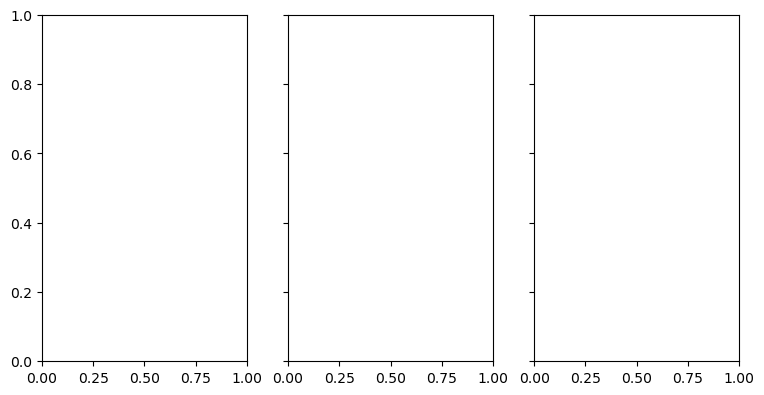

In [ ]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line
poly_color    = "#B8678F"   # muted rose for the polynomial fit

degrees = np.array([len(G.edges(n)) for n in G.nodes()])

for layer in range(layers):
    ax = axes[layer]
    y  = np.array(f0_list[layer])

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4,
            label="Linear fit")

    # Degree-2 polynomial fit
    poly_coeffs = np.polyfit(degrees, y, 2)
    poly_fn     = np.poly1d(poly_coeffs)
    ax.plot(x_range, poly_fn(x_range),
            color=poly_color,
            linewidth=1.6,
            linestyle=":",
            alpha=0.85,
            zorder=4,
            label="Poly. fit (deg. 2)")

    # R² for polynomial fit
    y_pred_poly = poly_fn(degrees)
    ss_res = np.sum((y - y_pred_poly) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_poly = 1 - ss_res / ss_tot

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with all metrics
    stats_text = (f"$R^2_{{lin}} = {r2:.3f}$\n"
                  f"$R^2_{{poly}} = {r2_poly:.3f}$\n"
                  f"$\\rho_s = {spearman_r:.3f}$\n"
                  f"$p = {spearman_p:.2e}$")
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Legend
    ax.legend(fontsize=8, framealpha=0.8, edgecolor="#cccccc",
              loc="best")

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Node degree", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Scalar curvature $f_0$", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Scalar Curvature and Node Degree",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

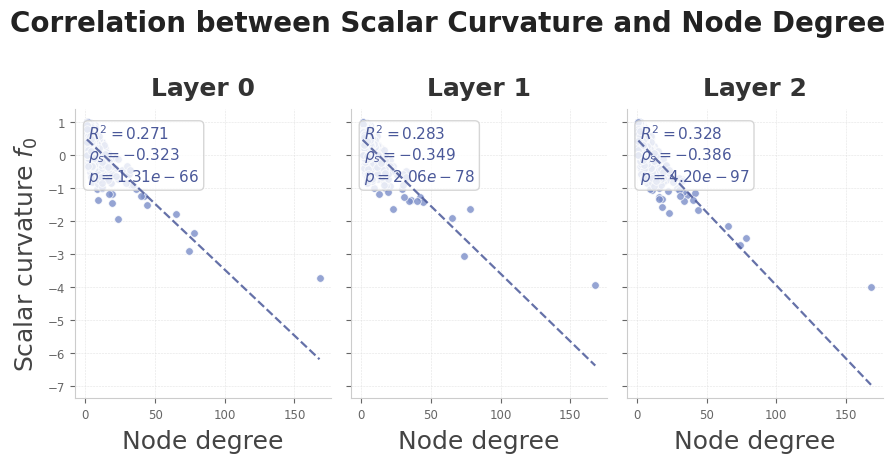

In [36]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line

degrees = [len(G.edges(n)) for n in G.nodes()]

for layer in range(layers):
    ax = axes[layer]
    y  = f0_list[layer]

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4)

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with both metrics
    stats_text = f"$R^2 = {r2:.3f}$\n$\\rho_s = {spearman_r:.3f}$\n$p = {spearman_p:.2e}$"
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=11,
            color=line_color,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Node degree", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Scalar curvature $f_0$", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Scalar Curvature and Node Degree",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

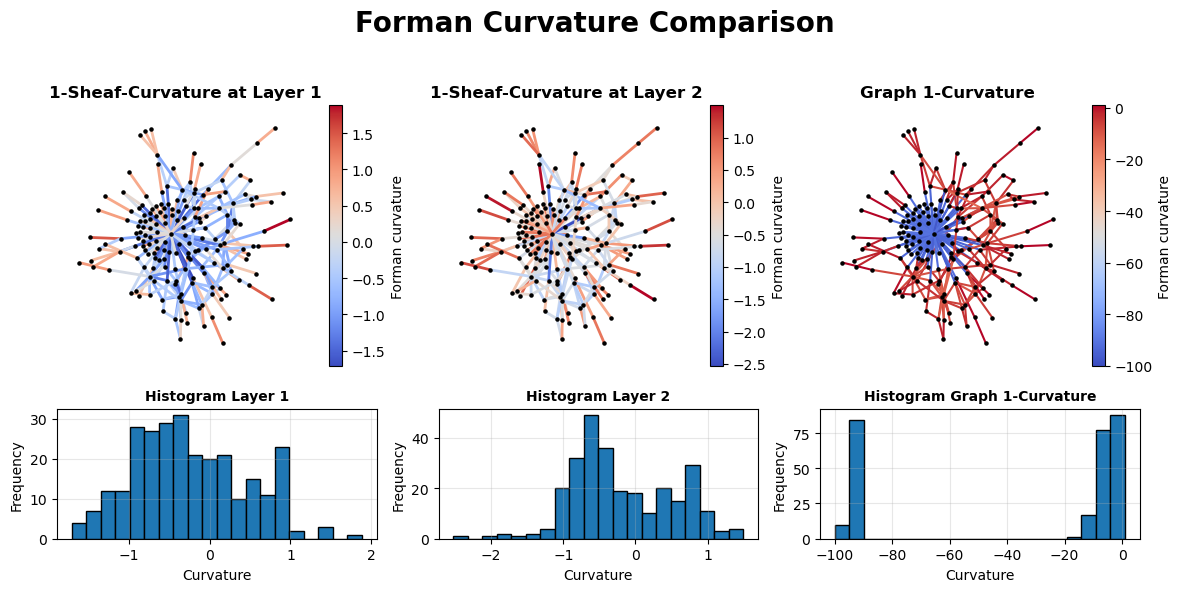

In [9]:
pos = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(4 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

for layer in range(layers):
    curvatures = np.asarray(f1_list[layer])

    # ----- Top row: graph -----
    ax_graph = ax[0, layer]
    nx.draw_networkx_nodes(
        G, ax=ax_graph, pos=pos,
        node_color='k', node_size=5
    )

    norm = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())
    nx.draw_networkx_edges(
        G, ax=ax_graph, pos=pos,
        edge_color=cmap(norm(curvatures)),
        width=2
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax_graph, label='Forman curvature')

    ax_graph.set_title(
        f"1-Sheaf-Curvature at Layer {layer+1}",
        fontweight="bold", fontsize=12
    )
    ax_graph.axis("off")

    # ----- Bottom row: histogram -----
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10, fontweight="bold"
    )
    ax_hist.set_xlabel("Curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ----- Last column: top graph curvature -----
curvatures_top = np.asarray(f1_top)

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G, ax=ax_graph, pos=pos,
    node_color='k', node_size=5
)

norm_top = plt.Normalize(vmin=curvatures_top.min(), vmax=curvatures_top.max())
nx.draw_networkx_edges(
    G, ax=ax_graph, pos=pos,
    edge_color=cmap(norm_top(curvatures_top)),
    width=1.5
)

sm_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm_top)
sm_top.set_array([])
plt.colorbar(sm_top, ax=ax_graph, label='Forman curvature')

ax_graph.set_title(
    "Graph 1-Curvature",
    fontweight="bold", fontsize=12
)
ax_graph.axis("off")

# ----- Bottom row: histogram for top curvature -----
ax_hist = ax[1, layers]
ax_hist.hist(curvatures_top, bins=20, edgecolor="black")
ax_hist.set_title(
    "Histogram Graph 1-Curvature",
    fontsize=10, fontweight="bold"
)
ax_hist.set_xlabel("Curvature")
ax_hist.set_ylabel("Frequency")
ax_hist.grid(alpha=0.3)

fig.suptitle("Forman Curvature Comparison", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/1-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

In [10]:
with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

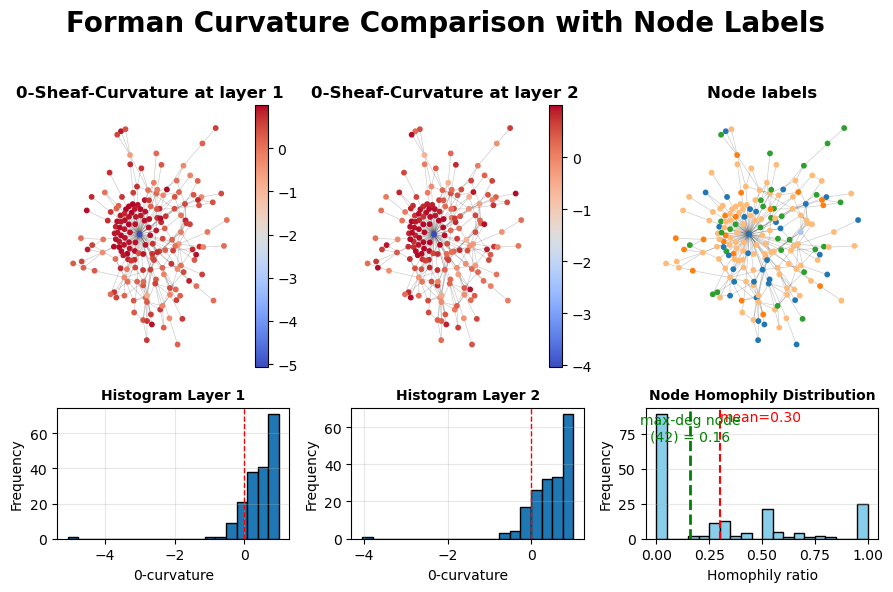

In [16]:
from tkinter import font


lab = df_node_feature["label"].values
# display(lab)

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3*(layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    curvatures = np.asarray(f0_list[layer])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(curvatures)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"0-Sheaf-Curvature at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("0-curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Forman Curvature Comparison with Node Labels", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf")
#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

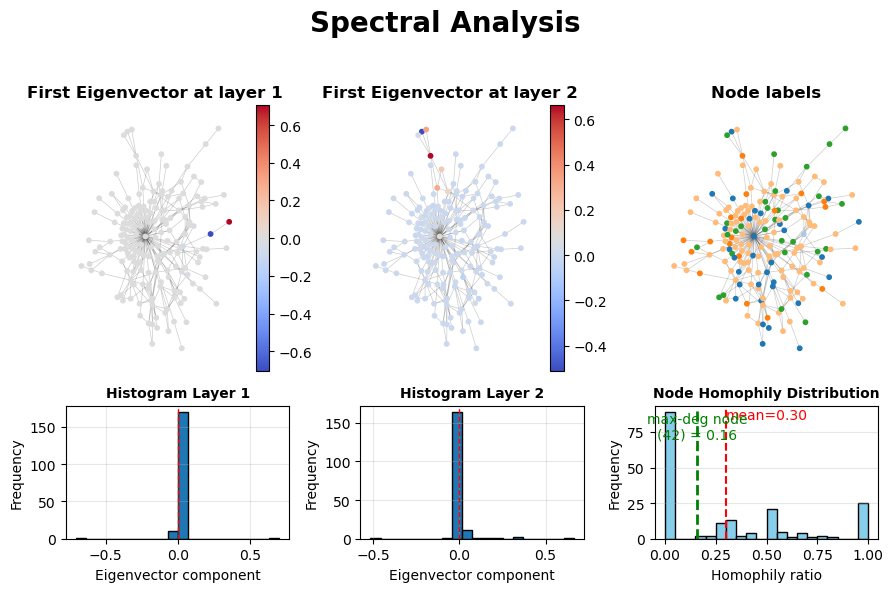

In [12]:
fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    eig00 = np.asarray(ev0_list[layer][:,0])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=eig00.min(), vmax=eig00.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(eig00)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"First Eigenvector at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(eig00, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("Eigenvector component")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)

# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Spectral Analysis", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)